In [1]:
import os
import gc
import random
import h5py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from scipy.stats import ttest_ind

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from sklearn.preprocessing import label_binarize

from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (
    Layer,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention
)

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
test_data = pd.read_csv(
    "datasets/CICIDS2017/train_test/CICIDS2017_Test_20.csv"
)

print(test_data.shape)

(487139, 41)


In [4]:
X_test = test_data.drop("label", axis=1).values

y_test = test_data["label"].values

print(X_test.shape)
print(y_test.shape)

(487139, 40)
(487139,)


In [5]:
NUM_FEATURES = X_test.shape[1]

NUM_CLASSES = len(np.unique(y_test))

print(NUM_FEATURES)

print(NUM_CLASSES)

40
14


In [6]:
@tf.keras.utils.register_keras_serializable()
class FeatureTokenizer(Layer):

    def __init__(self, num_features, embed_dim, **kwargs):

        super().__init__(**kwargs)

        self.num_features = num_features

        self.embed_dim = embed_dim

        self.proj = Dense(embed_dim)

    def build(self, input_shape):

        self.feature_embedding = self.add_weight(

            name="feature_embedding",

            shape=(1, self.num_features, self.embed_dim),

            initializer="random_normal",

            trainable=True

        )

    def call(self, x):

        x = tf.expand_dims(x, axis=-1)

        x = self.proj(x)

        return x + self.feature_embedding

    def get_config(self):

        config = super().get_config()

        config.update({

            "num_features": self.num_features,

            "embed_dim": self.embed_dim

        })

        return config

In [7]:
@tf.keras.utils.register_keras_serializable()
class CLSToken(Layer):

    def build(self, input_shape):

        self.cls = self.add_weight(

            name="cls_token",

            shape=(1,1,input_shape[-1]),

            initializer="zeros",

            trainable=True

        )

    def call(self, x):

        batch = tf.shape(x)[0]

        cls = tf.repeat(self.cls,

                        repeats=batch,

                        axis=0)

        return tf.concat([cls,x],axis=1)

In [8]:
@tf.keras.utils.register_keras_serializable()
class PositionEmbedding(Layer):

    def __init__(self,

                 sequence_length,

                 embed_dim,

                 **kwargs):

        super().__init__(**kwargs)

        self.sequence_length = sequence_length

        self.embed_dim = embed_dim

    def build(self,input_shape):

        self.pos_embedding=self.add_weight(

            name="position_embedding",

            shape=(1,self.sequence_length,self.embed_dim),

            initializer="random_normal",

            trainable=True

        )

    def call(self,x):

        return x+self.pos_embedding

    def get_config(self):

        config=super().get_config()

        config.update({

            "sequence_length":self.sequence_length,

            "embed_dim":self.embed_dim

        })

        return config

In [9]:
@tf.keras.utils.register_keras_serializable()
class TransformerBlock(Layer):

    def __init__(

        self,

        embed_dim,

        num_heads,

        ff_dim,

        dropout=0.15,

        **kwargs

    ):

        super().__init__(**kwargs)

        self.embed_dim=embed_dim

        self.num_heads=num_heads

        self.ff_dim=ff_dim

        self.dropout_rate=dropout

        self.norm1=LayerNormalization(epsilon=1e-6)

        self.att=MultiHeadAttention(

            num_heads=num_heads,

            key_dim=embed_dim//num_heads,

            dropout=dropout

        )

        self.drop1=Dropout(dropout)

        self.norm2=LayerNormalization(epsilon=1e-6)

        self.ffn=tf.keras.Sequential([

            Dense(ff_dim,activation="gelu"),

            Dropout(dropout),

            Dense(embed_dim)

        ])

        self.drop2=Dropout(dropout)

    def call(self,x,training=False):

        y=self.norm1(x)

        y=self.att(y,y,training=training)

        y=self.drop1(y,training=training)

        x=x+y

        y=self.norm2(x)

        y=self.ffn(y,training=training)

        y=self.drop2(y,training=training)

        return x+y

    def get_config(self):

        config=super().get_config()

        config.update({

            "embed_dim":self.embed_dim,

            "num_heads":self.num_heads,

            "ff_dim":self.ff_dim,

            "dropout":self.dropout_rate

        })

        return config

In [10]:
model = load_model(

    "Transformer_IDS_Final.keras",

    custom_objects={

        "FeatureTokenizer": FeatureTokenizer,

        "CLSToken": CLSToken,

        "PositionEmbedding": PositionEmbedding,

        "TransformerBlock": TransformerBlock

    },

    compile=False

)

print(model.summary())

c:\Users\farda\anaconda3\envs\myenv\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'transformer_block_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\farda\anaconda3\envs\myenv\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'transformer_block_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "FTTransformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_tokenizer_1             │ (None, 40, 192)        │         8,064 │
│ (FeatureTokenizer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cls_token_1 (CLSToken)          │ (None, 41, 192)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ position_embedding_1            │ (None, 41, 192)        │         7,872 │
│ (PositionEmbedding)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 41, 192)        │       247,744 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 41, 192)        │       247,744 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item_1 (GetItem)            │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_13          │ (None, 192)            │           384 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 14)             │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,870 (2.08 MB)

 Trainable params: 545,870 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

None


In [11]:
sample = model.predict(X_test[:5])

print(sample.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 907ms/step
(5, 14)


In [12]:
# ==========================================
# Monte Carlo Dropout Settings
# ==========================================

MC_RUNS = 30

BATCH_SIZE = 256

NUM_SAMPLES = len(X_test)

NUM_CLASSES = model.output_shape[-1]

print("Samples :", NUM_SAMPLES)
print("Classes :", NUM_CLASSES)

Samples : 487139
Classes : 14


In [13]:
HDF5_FILE = "mc_predictions.h5"

In [14]:
if not os.path.exists(HDF5_FILE):

    h5f = h5py.File(HDF5_FILE, "w")

    predictions_ds = h5f.create_dataset(

        "predictions",

        shape=(MC_RUNS, NUM_SAMPLES, NUM_CLASSES),

        dtype=np.float32,

        compression="gzip"

    )

    completed_runs = h5f.create_dataset(

        "completed_runs",

        shape=(MC_RUNS,),

        dtype=np.int8

    )

    completed_runs[:] = 0

else:

    h5f = h5py.File(HDF5_FILE, "r+")

    predictions_ds = h5f["predictions"]

    completed_runs = h5f["completed_runs"]

In [15]:
for mc in range(MC_RUNS):

    if completed_runs[mc] == 1:

        print(f"Skipping Run {mc+1}")

        continue

    print(f"\nMonte Carlo Run {mc+1}/{MC_RUNS}")

    for start in range(0, NUM_SAMPLES, BATCH_SIZE):

        end = min(start + BATCH_SIZE, NUM_SAMPLES)

        x_batch = X_test[start:end]

        preds = model(

            x_batch,

            training=True      # KEEP DROPOUT ACTIVE

        ).numpy()

        predictions_ds[mc, start:end] = preds

    completed_runs[mc] = 1

    h5f.flush()

    gc.collect()

    print("Saved ✔")


Monte Carlo Run 1/30


Saved ✔

Monte Carlo Run 2/30
Saved ✔

Monte Carlo Run 3/30
Saved ✔

Monte Carlo Run 4/30
Saved ✔

Monte Carlo Run 5/30
Saved ✔

Monte Carlo Run 6/30
Saved ✔

Monte Carlo Run 7/30
Saved ✔

Monte Carlo Run 8/30
Saved ✔

Monte Carlo Run 9/30
Saved ✔

Monte Carlo Run 10/30
Saved ✔

Monte Carlo Run 11/30
Saved ✔

Monte Carlo Run 12/30
Saved ✔

Monte Carlo Run 13/30
Saved ✔

Monte Carlo Run 14/30
Saved ✔

Monte Carlo Run 15/30
Saved ✔

Monte Carlo Run 16/30
Saved ✔

Monte Carlo Run 17/30
Saved ✔

Monte Carlo Run 18/30
Saved ✔

Monte Carlo Run 19/30
Saved ✔

Monte Carlo Run 20/30
Saved ✔

Monte Carlo Run 21/30
Saved ✔

Monte Carlo Run 22/30
Saved ✔

Monte Carlo Run 23/30
Saved ✔

Monte Carlo Run 24/30
Saved ✔

Monte Carlo Run 25/30
Saved ✔

Monte Carlo Run 26/30
Saved ✔

Monte Carlo Run 27/30
Saved ✔

Monte Carlo Run 28/30
Saved ✔

Monte Carlo Run 29/30
Saved ✔

Monte Carlo Run 30/30
Saved ✔


In [16]:
h5f.close()

print("MC Dropout Completed")

MC Dropout Completed


In [17]:
with h5py.File(HDF5_FILE, "r") as f:

    print(f.keys())

    print(f["predictions"].shape)

    print(f["completed_runs"][:])

<KeysViewHDF5 ['completed_runs', 'predictions']>
(30, 487139, 14)
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [18]:
with h5py.File(HDF5_FILE, "r") as f:

    mc_predictions = f["predictions"][:]

print("MC Predictions Shape:", mc_predictions.shape)

MC Predictions Shape: (30, 487139, 14)


In [19]:
mean_probs = np.mean(

    mc_predictions,

    axis=0

)

print(mean_probs.shape)

(487139, 14)


In [20]:
pred_classes = np.argmax(

    mean_probs,

    axis=1

)

print(pred_classes.shape)

(487139,)


In [21]:
confidence = np.max(

    mean_probs,

    axis=1

)

print(confidence.shape)

(487139,)


In [22]:
prediction_uncertainty = np.std(

    mc_predictions,

    axis=0

).mean(axis=1)

print(prediction_uncertainty.shape)

(487139,)


In [23]:
epsilon = 1e-10

entropy = -np.sum(

    mean_probs *

    np.log(mean_probs + epsilon),

    axis=1

)

print(entropy.shape)

(487139,)


In [24]:
true_classes = y_test.copy()

print(true_classes.shape)

(487139,)


In [25]:
print(len(true_classes))
print(len(pred_classes))
print(len(confidence))
print(len(prediction_uncertainty))
print(len(entropy))

487139
487139
487139
487139
487139


In [26]:
results = pd.DataFrame({

    "True_Class": true_classes,

    "Predicted_Class": pred_classes,

    "Confidence": confidence,

    "Std_Uncertainty": prediction_uncertainty,

    "Predictive_Entropy": entropy

})

results.head()

,True_Class,Predicted_Class,Confidence,Std_Uncertainty,Predictive_Entropy
0,0,0,0.997124,0.000734,0.024980
1,0,0,0.906842,0.008220,0.437950
2,9,9,0.999464,0.000176,0.004976
3,0,0,0.997742,0.001055,0.019713
4,0,0,0.990689,0.002271,0.062217


In [27]:
results.to_csv(

    "mc_results.csv",

    index=False

)

print("MC results saved successfully.")

MC results saved successfully.


In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(

    true_classes,

    pred_classes

)

print(f"Accuracy : {accuracy:.4f}")

print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 0.9935
Accuracy : 99.35%


In [29]:
print(

    classification_report(

        true_classes,

        pred_classes,

        digits=4,

        zero_division=0

    )

)

              precision    recall  f1-score   support

           0     0.9941    0.9981    0.9961    357145
           1     0.9928    1.0000    0.9964      1102
           2     1.0000    0.9996    0.9998     19147
           3     0.9733    0.9594    0.9663      1673
           4     0.9906    0.9969    0.9937     69479
           5     0.9136    0.8710    0.8918      1372
           6     0.9443    0.8676    0.9043      1035
           7     0.9025    0.8300    0.8647      1906
           8     0.0000    0.0000    0.0000         2
           9     0.9999    0.9947    0.9973     32265
          10     1.0000    0.5017    0.6682      1190
          11     0.9000    0.0165    0.0323       547
          12     0.0000    0.0000    0.0000         5
          13     1.0000    0.0111    0.0219       271

    accuracy                         0.9935    487139
   macro avg     0.8294    0.6462    0.6666    487139
weighted avg     0.9933    0.9935    0.9924    487139



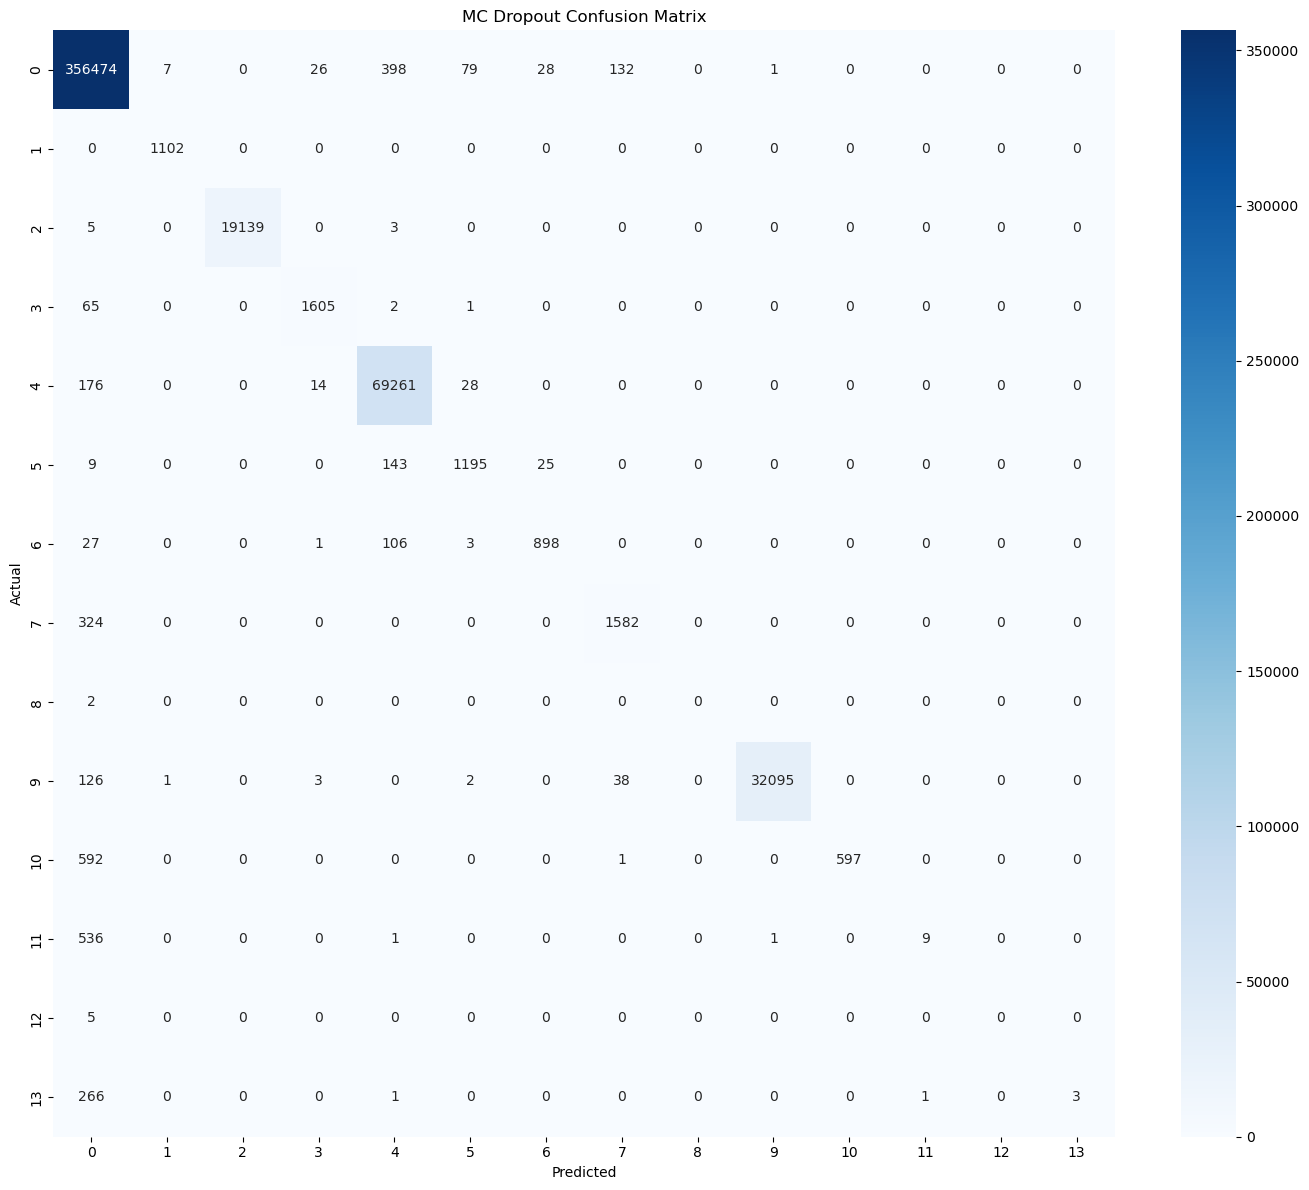

In [30]:
cm = confusion_matrix(

    true_classes,

    pred_classes

)

plt.figure(figsize=(14,12))

sns.heatmap(

    cm,

    cmap="Blues",

    fmt="d",

    annot=True

)

plt.title("MC Dropout Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

In [31]:
correct_mask = pred_classes == true_classes

wrong_mask = ~correct_mask

print("Total Samples :", len(true_classes))

print("Correct :", np.sum(correct_mask))

print("Wrong :", np.sum(wrong_mask))

print("Accuracy :", np.mean(correct_mask))

Total Samples : 487139
Correct : 483960
Wrong : 3179
Accuracy : 0.9934741418773697


In [32]:
print("Correct Mean Confidence :",

      confidence[correct_mask].mean())

print("Wrong Mean Confidence :",

      confidence[wrong_mask].mean())

Correct Mean Confidence : 0.9657298
Wrong Mean Confidence : 0.63264006


In [33]:
print("Correct Mean Uncertainty :",

      prediction_uncertainty[correct_mask].mean())

print("Wrong Mean Uncertainty :",

      prediction_uncertainty[wrong_mask].mean())

Correct Mean Uncertainty : 0.0025564996
Wrong Mean Uncertainty : 0.009785396


In [34]:
print("Correct Mean Entropy :",

      entropy[correct_mask].mean())

print("Wrong Mean Entropy :",

      entropy[wrong_mask].mean())

Correct Mean Entropy : 0.11286228
Wrong Mean Entropy : 0.7959051


In [35]:
t_stat, p_value = ttest_ind(

    prediction_uncertainty[correct_mask],

    prediction_uncertainty[wrong_mask],

    equal_var=False

)

print("T-statistic :", t_stat)

print("P-value :", p_value)

T-statistic : -60.11867
P-value : 0.0


In [36]:
def expected_calibration_error(

    y_true,

    y_pred,

    confidence,

    n_bins=15

):

    bins = np.linspace(0,1,n_bins+1)

    ece = 0

    for i in range(n_bins):

        mask = (

            (confidence > bins[i]) &

            (confidence <= bins[i+1])

        )

        if np.sum(mask)==0:

            continue

        acc = np.mean(

            y_true[mask]==y_pred[mask]

        )

        conf = np.mean(

            confidence[mask]

        )

        ece += (

            abs(acc-conf)

            *

            np.sum(mask)

            /

            len(y_true)

        )

    return ece

In [37]:
ece = expected_calibration_error(

    true_classes,

    pred_classes,

    confidence

)

print("ECE :", ece)

ECE : 0.029929724953503763


In [38]:
y_true_onehot = label_binarize(

    true_classes,

    classes=np.arange(NUM_CLASSES)

)

brier_score = np.mean(

    np.sum(

        (mean_probs-y_true_onehot)**2,

        axis=1

    )

)

print("Brier Score :", brier_score)

Brier Score : 0.01935858554507303


In [39]:
def reliability_diagram(

    y_true,

    y_pred,

    confidence,

    n_bins=15

):

    bins = np.linspace(0,1,n_bins+1)

    accs=[]

    confs=[]

    for i in range(n_bins):

        mask=(

            (confidence>bins[i])

            &

            (confidence<=bins[i+1])

        )

        if np.sum(mask)==0:

            continue

        accs.append(

            np.mean(

                y_true[mask]==y_pred[mask]

            )

        )

        confs.append(

            np.mean(

                confidence[mask]

            )

        )

    plt.figure(figsize=(6,6))

    plt.plot(

        [0,1],

        [0,1],

        "--",

        color="gray",

        label="Perfect"

    )

    plt.plot(

        confs,

        accs,

        "o-",

        linewidth=2,

        label="Transformer"

    )

    plt.xlabel("Confidence")

    plt.ylabel("Accuracy")

    plt.title("Reliability Diagram")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.show()

    return accs, confs

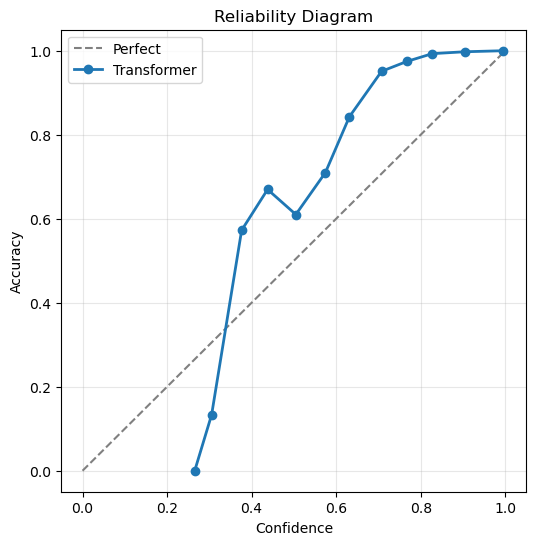

In [40]:
accs, confs = reliability_diagram(

    true_classes,

    pred_classes,

    confidence

)

In [41]:
calibration_table = pd.DataFrame({

    "Confidence": confs,

    "Accuracy": accs

})

calibration_table.to_csv(

    "calibration_table.csv",

    index=False

)

calibration_table.head()

,Confidence,Accuracy
0,0.265365,0.000000
1,0.305376,0.133333
2,0.376373,0.572581
3,0.437744,0.669697
4,0.504583,0.610046


# Viualization

# MC Predictions + ROC Curves + AUROC

In [3]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score
)

# -------------------------------------------------
# Load Test Labels
# -------------------------------------------------

test_data = pd.read_csv(
    "datasets/CICIDS2017/train_test/CICIDS2017_Test_20.csv"
)

y_test = test_data["label"].values

print("Test Samples :", len(y_test))

# -------------------------------------------------
# Load MC Predictions
# -------------------------------------------------

with h5py.File("mc_predictions.h5", "r") as f:

    mc_predictions = f["predictions"][:]

print("MC Shape :", mc_predictions.shape)

# -------------------------------------------------
# Mean Probability
# -------------------------------------------------

mean_probs = np.mean(
    mc_predictions,
    axis=0
)

print(mean_probs.shape)

NUM_CLASSES = mean_probs.shape[1]

print("Classes :", NUM_CLASSES)

# -------------------------------------------------
# One-Hot Labels
# -------------------------------------------------

y_true_onehot = label_binarize(
    y_test,
    classes=np.arange(NUM_CLASSES)
)

print(y_true_onehot.shape)

Test Samples : 487139
MC Shape : (30, 487139, 14)
(487139, 14)
Classes : 14
(487139, 14)


# Per-Class ROC Curves

In [4]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(NUM_CLASSES):

    fpr[i], tpr[i], _ = roc_curve(
        y_true_onehot[:, i],
        mean_probs[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

print(roc_auc)

{0: 0.9996739518278216, 1: 0.9999989451334481, 2: 0.9999115365922324, 3: 0.9998961566149729, 4: 0.9998317395861722, 5: 0.9986214498833412, 6: 0.9996026535662712, 7: 0.9995882993860077, 8: 0.19275686305905732, 9: 0.9999895265969848, 10: 0.9986507073891334, 11: 0.9892882190615127, 12: 0.9972200667578119, 13: 0.9931956029695282}


# Plot All ROC Curves

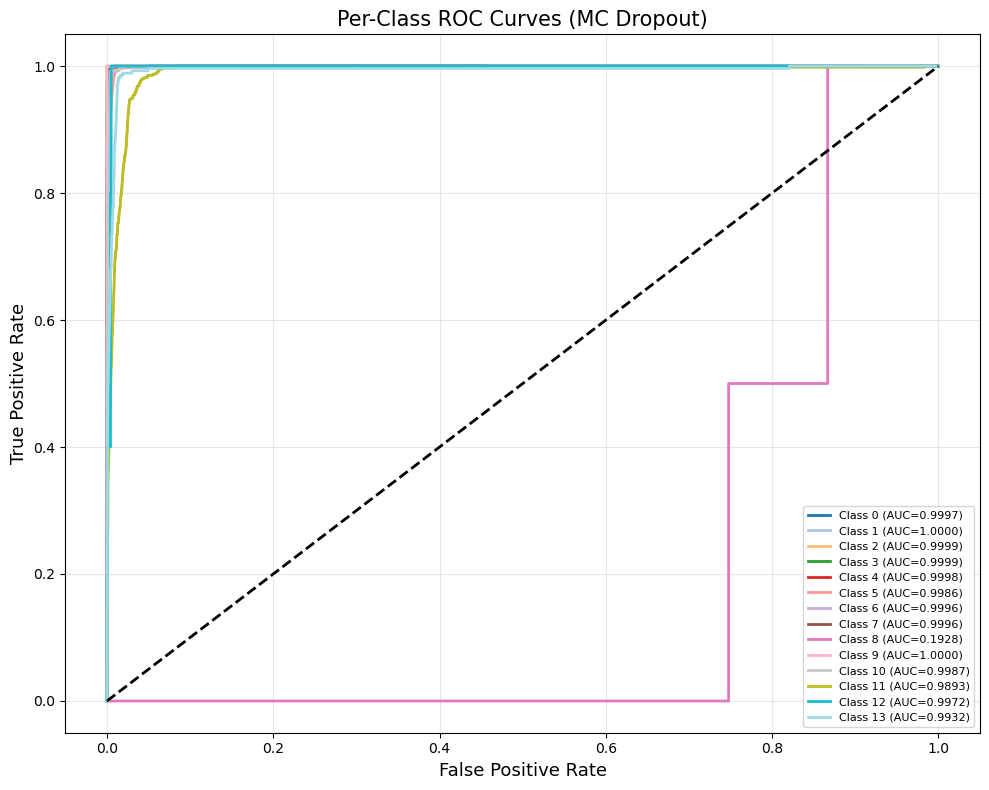

In [5]:
plt.figure(figsize=(10,8))

colors = plt.cm.tab20(
    np.linspace(0,1,NUM_CLASSES)
)

for i, color in zip(range(NUM_CLASSES), colors):

    plt.plot(
        fpr[i],
        tpr[i],
        lw=2,
        color=color,
        label=f"Class {i} (AUC={roc_auc[i]:.4f})"
    )

plt.plot(
    [0,1],
    [0,1],
    "k--",
    linewidth=2
)

plt.xlabel("False Positive Rate", fontsize=13)

plt.ylabel("True Positive Rate", fontsize=13)

plt.title(
    "Per-Class ROC Curves (MC Dropout)",
    fontsize=15
)

plt.legend(
    fontsize=8,
    loc="lower right"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "ROC_Per_Class.png",
    dpi=300
)

plt.show()

# Micro-Average ROC

In [6]:
fpr_micro, tpr_micro, _ = roc_curve(

    y_true_onehot.ravel(),

    mean_probs.ravel()

)

auc_micro = auc(

    fpr_micro,

    tpr_micro

)

print("Micro AUROC :", auc_micro)

Micro AUROC : 0.9999523842506773


# Macro-Average ROC

In [7]:
all_fpr = np.unique(

    np.concatenate(

        [fpr[i] for i in range(NUM_CLASSES)]

    )

)

mean_tpr = np.zeros_like(all_fpr)

for i in range(NUM_CLASSES):

    mean_tpr += np.interp(

        all_fpr,

        fpr[i],

        tpr[i]

    )

mean_tpr /= NUM_CLASSES

auc_macro = auc(

    all_fpr,

    mean_tpr

)

print("Macro AUROC :", auc_macro)

Macro AUROC : 0.940589735698242


# Plot Micro + Macro ROC

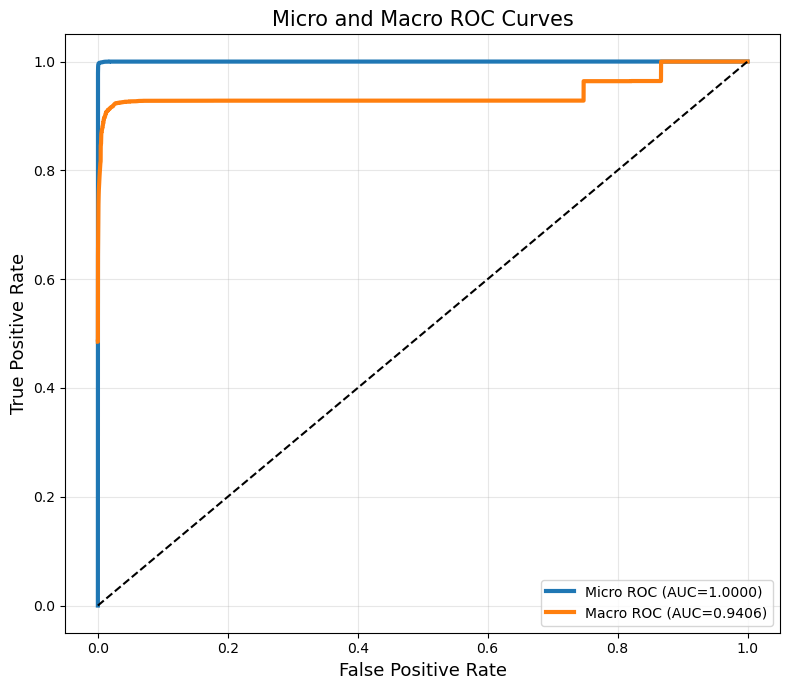

In [8]:
plt.figure(figsize=(8,7))

plt.plot(

    fpr_micro,

    tpr_micro,

    label=f"Micro ROC (AUC={auc_micro:.4f})",

    linewidth=3

)

plt.plot(

    all_fpr,

    mean_tpr,

    label=f"Macro ROC (AUC={auc_macro:.4f})",

    linewidth=3

)

plt.plot(

    [0,1],

    [0,1],

    "--",

    color="black"

)

plt.xlabel("False Positive Rate", fontsize=13)

plt.ylabel("True Positive Rate", fontsize=13)

plt.title(

    "Micro and Macro ROC Curves",

    fontsize=15

)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    "ROC_Micro_Macro.png",

    dpi=300

)

plt.show()

# AUROC Table

In [9]:
auc_table = pd.DataFrame({

    "Class": np.arange(NUM_CLASSES),

    "AUROC": [roc_auc[i] for i in range(NUM_CLASSES)]

})

auc_table.loc[len(auc_table)] = [

    "Micro",

    auc_micro

]

auc_table.loc[len(auc_table)] = [

    "Macro",

    auc_macro

]

print(auc_table)

auc_table.to_csv(

    "AUROC_Table.csv",

    index=False

)

    Class     AUROC
0       0  0.999674
1       1  0.999999
2       2  0.999912
3       3  0.999896
4       4  0.999832
5       5  0.998621
6       6  0.999603
7       7  0.999588
8       8  0.192757
9       9  0.999990
10     10  0.998651
11     11  0.989288
12     12  0.997220
13     13  0.993196
14  Micro  0.999952
15  Macro  0.940590


# Overall AUROC (One-vs-Rest)

In [10]:
overall_auc = roc_auc_score(

    y_true_onehot,

    mean_probs,

    average="weighted",

    multi_class="ovr"

)

print("\nWeighted AUROC :", overall_auc)


Weighted AUROC : 0.9997036402936066


# Precision–Recall Curves + AUPRC

In [11]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

# Compute PR Curves

In [12]:
precision = {}
recall = {}
average_precision = {}

for i in range(NUM_CLASSES):

    precision[i], recall[i], _ = precision_recall_curve(
        y_true_onehot[:, i],
        mean_probs[:, i]
    )

    average_precision[i] = average_precision_score(
        y_true_onehot[:, i],
        mean_probs[:, i]
    )

print("Done.")

Done.


# Plot Per-Class PR Curves

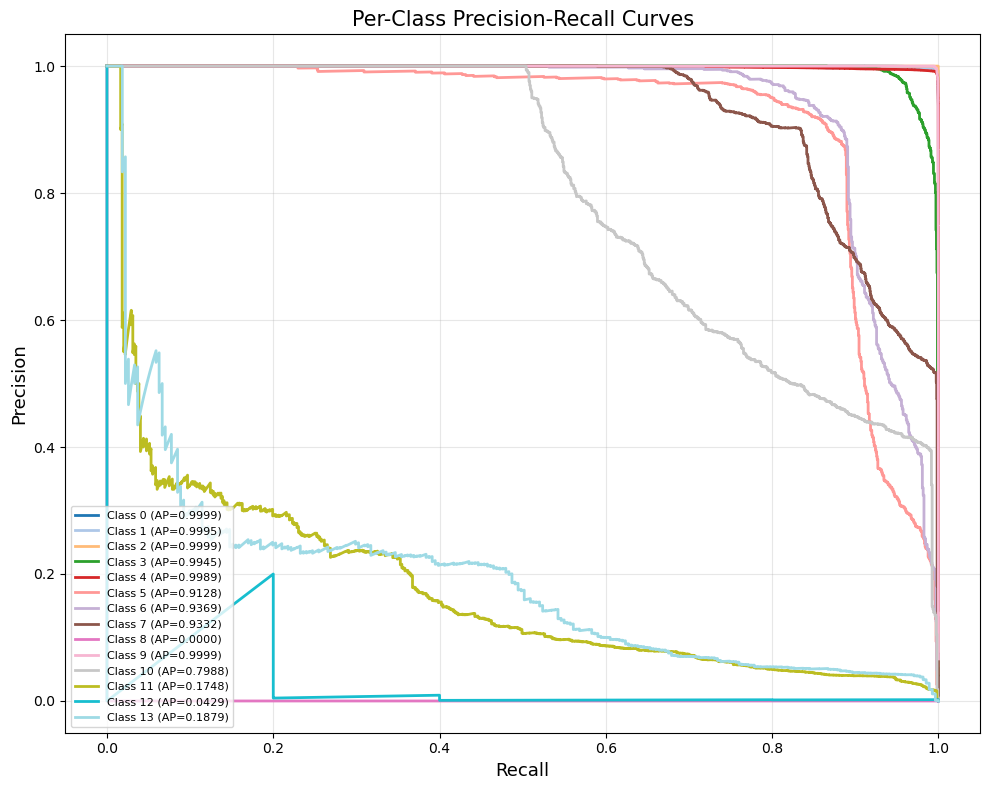

In [13]:
plt.figure(figsize=(10,8))

colors = plt.cm.tab20(
    np.linspace(0,1,NUM_CLASSES)
)

for i, color in zip(range(NUM_CLASSES), colors):

    plt.plot(
        recall[i],
        precision[i],
        color=color,
        lw=2,
        label=f"Class {i} (AP={average_precision[i]:.4f})"
    )

plt.xlabel("Recall", fontsize=13)

plt.ylabel("Precision", fontsize=13)

plt.title(
    "Per-Class Precision-Recall Curves",
    fontsize=15
)

plt.grid(alpha=0.3)

plt.legend(
    fontsize=8,
    loc="lower left"
)

plt.tight_layout()

plt.savefig(
    "PR_Per_Class.png",
    dpi=300
)

plt.show()

# Micro-Average PR Curve

In [14]:
precision_micro, recall_micro, _ = precision_recall_curve(

    y_true_onehot.ravel(),

    mean_probs.ravel()

)

ap_micro = average_precision_score(

    y_true_onehot,

    mean_probs,

    average="micro"

)

print("Micro Average Precision :", ap_micro)

Micro Average Precision : 0.9995734431720458


# Plot Micro PR Curve

C:\Users\farda\AppData\Local\Temp\ipykernel_3944\4281452557.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\farda\AppData\Local\Temp\ipykernel_3944\4281452557.py:33: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(
c:\Users\farda\anaconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


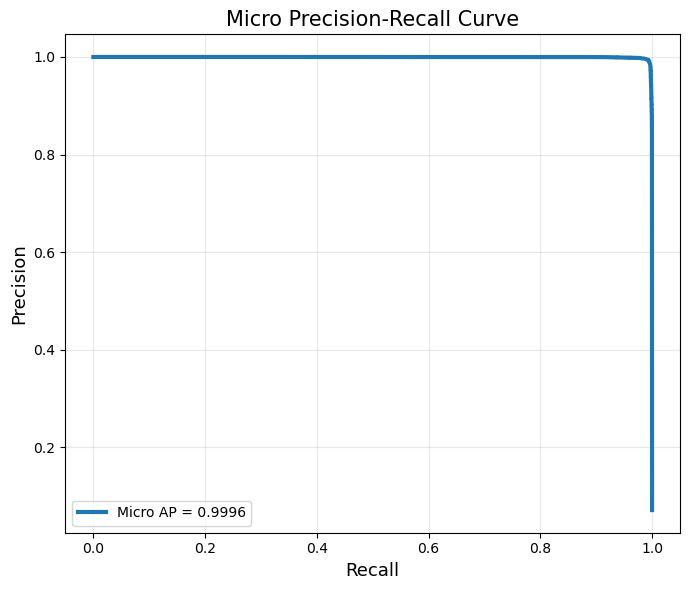

In [15]:
plt.figure(figsize=(7,6))

plt.plot(

    recall_micro,

    precision_micro,

    linewidth=3,

    label=f"Micro AP = {ap_micro:.4f}"

)

plt.xlabel("Recall", fontsize=13)

plt.ylabel("Precision", fontsize=13)

plt.title(

    "Micro Precision-Recall Curve",

    fontsize=15

)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(

    "PR_Micro.png",

    dpi=300

)

plt.show()

# Macro Average Precision

In [16]:
macro_ap = average_precision_score(

    y_true_onehot,

    mean_probs,

    average="macro"

)

weighted_ap = average_precision_score(

    y_true_onehot,

    mean_probs,

    average="weighted"

)

print("Macro AP    :", macro_ap)

print("Weighted AP :", weighted_ap)

Macro AP    : 0.7128428184471283
Weighted AP : 0.9971959409670285


# Save AUPRC Table

In [17]:
ap_table = pd.DataFrame({

    "Class": np.arange(NUM_CLASSES),

    "Average Precision": [
        average_precision[i]
        for i in range(NUM_CLASSES)
    ]

})

ap_table.loc[len(ap_table)] = [

    "Micro",

    ap_micro

]

ap_table.loc[len(ap_table)] = [

    "Macro",

    macro_ap

]

ap_table.loc[len(ap_table)] = [

    "Weighted",

    weighted_ap

]

print(ap_table)

ap_table.to_csv(

    "AUPRC_Table.csv",

    index=False

)

       Class  Average Precision
0          0           0.999882
1          1           0.999499
2          2           0.999857
3          3           0.994495
4          4           0.998885
5          5           0.912846
6          6           0.936867
7          7           0.933217
8          8           0.000004
9          9           0.999881
10        10           0.798783
11        11           0.174786
12        12           0.042907
13        13           0.187891
14     Micro           0.999573
15     Macro           0.712843
16  Weighted           0.997196


# Uncertainty Analysis Figures

In [19]:
import h5py
import numpy as np
import pandas as pd

# Load test labels
test_data = pd.read_csv(
    "datasets/CICIDS2017/train_test/CICIDS2017_Test_20.csv"
)

true_classes = test_data["label"].values

# Load MC predictions
with h5py.File("mc_predictions.h5", "r") as f:
    mc_predictions = f["predictions"][:]

print("MC Predictions:", mc_predictions.shape)

# Mean probability
mean_probs = np.mean(mc_predictions, axis=0)

# Predicted class
pred_classes = np.argmax(mean_probs, axis=1)

# Confidence
confidence = np.max(mean_probs, axis=1)

# Predictive uncertainty
prediction_uncertainty = np.std(
    mc_predictions,
    axis=0
).mean(axis=1)

# Predictive entropy
epsilon = 1e-10

entropy = -np.sum(
    mean_probs * np.log(mean_probs + epsilon),
    axis=1
)

print("Done.")
print("True labels :", true_classes.shape)
print("Predictions :", pred_classes.shape)
print("Confidence  :", confidence.shape)
print("Uncertainty :", prediction_uncertainty.shape)
print("Entropy     :", entropy.shape)

MC Predictions: (30, 487139, 14)
Done.
True labels : (487139,)
Predictions : (487139,)
Confidence  : (487139,)
Uncertainty : (487139,)
Entropy     : (487139,)


In [20]:
correct_mask = pred_classes == true_classes
wrong_mask = ~correct_mask

print("Correct :", np.sum(correct_mask))
print("Wrong   :", np.sum(wrong_mask))

Correct : 483960
Wrong   : 3179


# Confidence Histogram

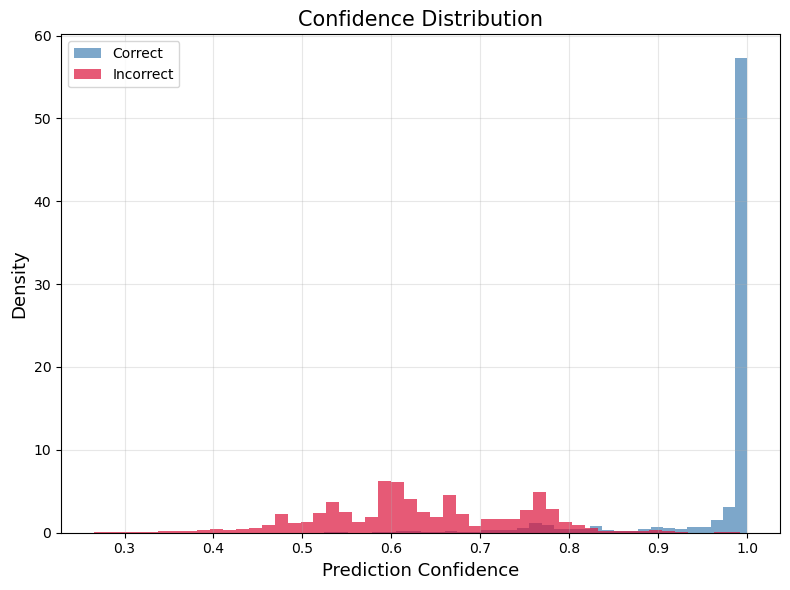

In [21]:
plt.figure(figsize=(8,6))

plt.hist(
    confidence[correct_mask],
    bins=50,
    alpha=0.7,
    density=True,
    label="Correct",
    color="steelblue"
)

plt.hist(
    confidence[wrong_mask],
    bins=50,
    alpha=0.7,
    density=True,
    label="Incorrect",
    color="crimson"
)

plt.xlabel("Prediction Confidence", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.title("Confidence Distribution", fontsize=15)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Confidence_Histogram.png",
    dpi=300
)

plt.show()

# Predictive Entropy Histogram

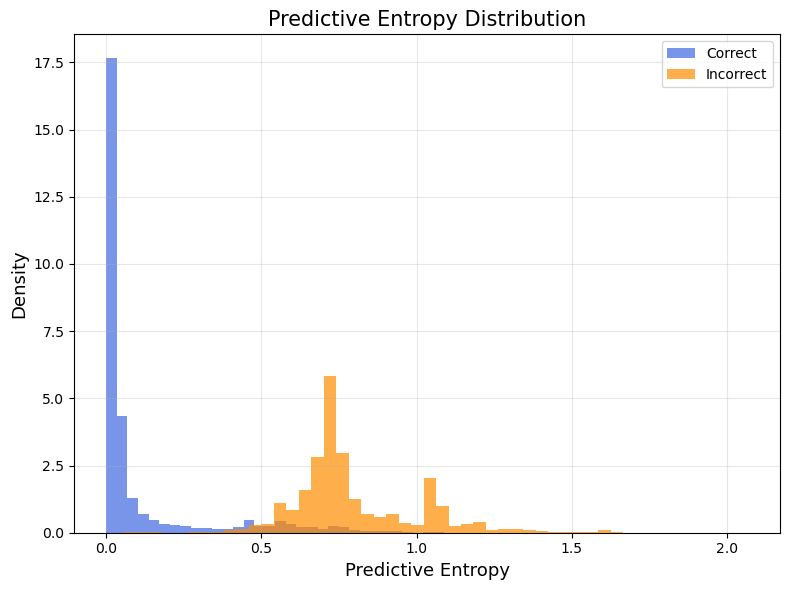

In [22]:
plt.figure(figsize=(8,6))

plt.hist(
    entropy[correct_mask],
    bins=50,
    density=True,
    alpha=0.7,
    label="Correct",
    color="royalblue"
)

plt.hist(
    entropy[wrong_mask],
    bins=50,
    density=True,
    alpha=0.7,
    label="Incorrect",
    color="darkorange"
)

plt.xlabel("Predictive Entropy", fontsize=13)
plt.ylabel("Density", fontsize=13)

plt.title(
    "Predictive Entropy Distribution",
    fontsize=15
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Entropy_Histogram.png",
    dpi=300
)

plt.show()

# MC Dropout Uncertainty Histogram

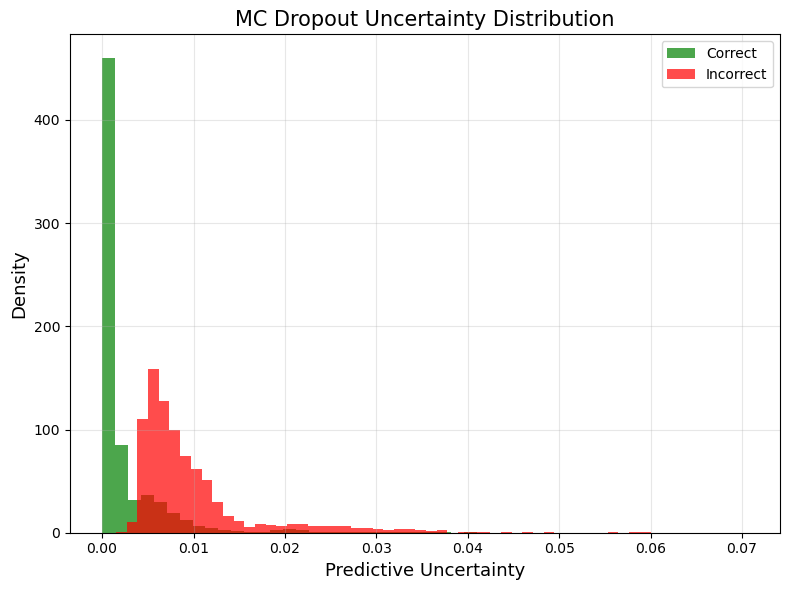

In [23]:
plt.figure(figsize=(8,6))

plt.hist(
    prediction_uncertainty[correct_mask],
    bins=50,
    density=True,
    alpha=0.7,
    label="Correct",
    color="green"
)

plt.hist(
    prediction_uncertainty[wrong_mask],
    bins=50,
    density=True,
    alpha=0.7,
    label="Incorrect",
    color="red"
)

plt.xlabel("Predictive Uncertainty", fontsize=13)
plt.ylabel("Density", fontsize=13)

plt.title(
    "MC Dropout Uncertainty Distribution",
    fontsize=15
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Uncertainty_Histogram.png",
    dpi=300
)

plt.show()

# Confidence Boxplot

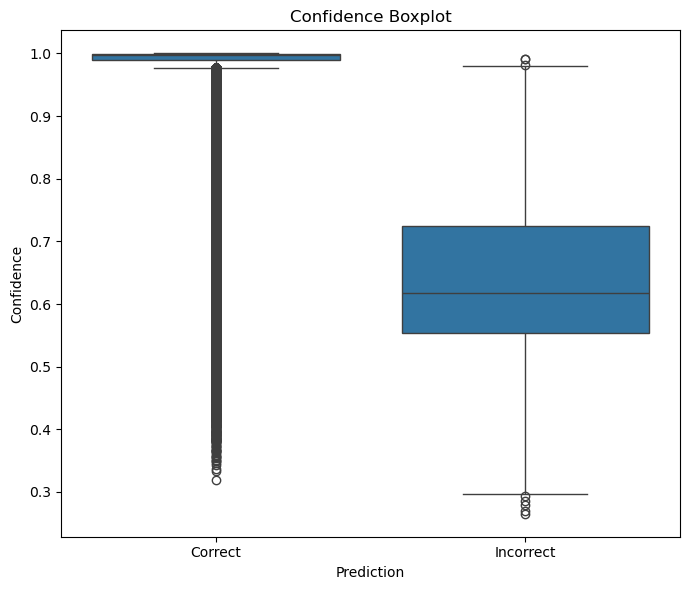

In [25]:
import seaborn as sns
box_data = pd.DataFrame({

    "Confidence": np.concatenate([
        confidence[correct_mask],
        confidence[wrong_mask]
    ]),

    "Prediction": (
        ["Correct"] * np.sum(correct_mask)
        +
        ["Incorrect"] * np.sum(wrong_mask)
    )

})

plt.figure(figsize=(7,6))

sns.boxplot(
    x="Prediction",
    y="Confidence",
    data=box_data
)

plt.title("Confidence Boxplot")

plt.tight_layout()

plt.savefig(
    "Confidence_Boxplot.png",
    dpi=300
)

plt.show()

# Entropy Boxplot

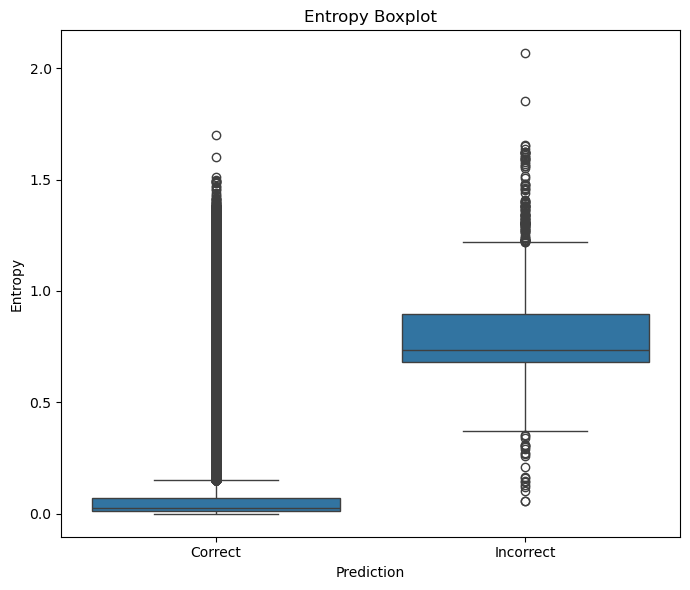

In [26]:
entropy_data = pd.DataFrame({

    "Entropy": np.concatenate([
        entropy[correct_mask],
        entropy[wrong_mask]
    ]),

    "Prediction": (
        ["Correct"] * np.sum(correct_mask)
        +
        ["Incorrect"] * np.sum(wrong_mask)
    )

})

plt.figure(figsize=(7,6))

sns.boxplot(
    x="Prediction",
    y="Entropy",
    data=entropy_data
)

plt.title("Entropy Boxplot")

plt.tight_layout()

plt.savefig(
    "Entropy_Boxplot.png",
    dpi=300
)

plt.show()

# Uncertainty Boxplot

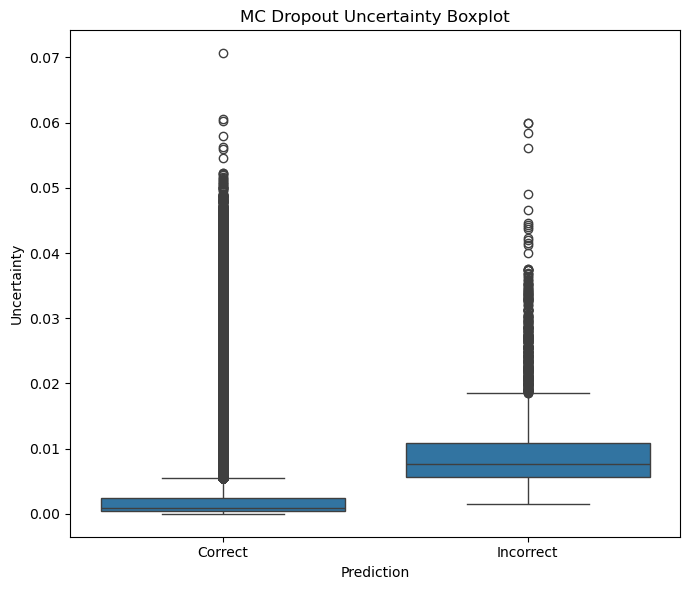

In [27]:
unc_data = pd.DataFrame({

    "Uncertainty": np.concatenate([
        prediction_uncertainty[correct_mask],
        prediction_uncertainty[wrong_mask]
    ]),

    "Prediction": (
        ["Correct"] * np.sum(correct_mask)
        +
        ["Incorrect"] * np.sum(wrong_mask)
    )

})

plt.figure(figsize=(7,6))

sns.boxplot(
    x="Prediction",
    y="Uncertainty",
    data=unc_data
)

plt.title("MC Dropout Uncertainty Boxplot")

plt.tight_layout()

plt.savefig(
    "Uncertainty_Boxplot.png",
    dpi=300
)

plt.show()

# Confidence Violin Plot

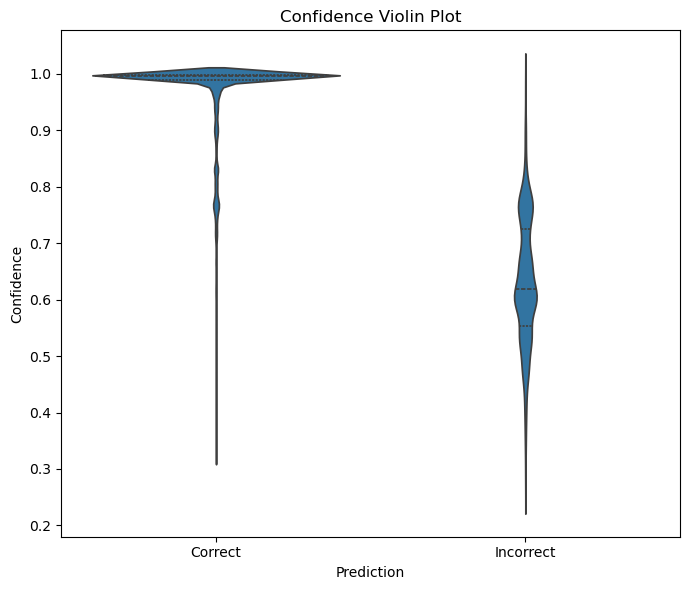

In [28]:
plt.figure(figsize=(7,6))

sns.violinplot(
    x="Prediction",
    y="Confidence",
    data=box_data,
    inner="quartile"
)

plt.title("Confidence Violin Plot")

plt.tight_layout()

plt.savefig(
    "Confidence_Violin.png",
    dpi=300
)

plt.show()

# Entropy Violin Plot

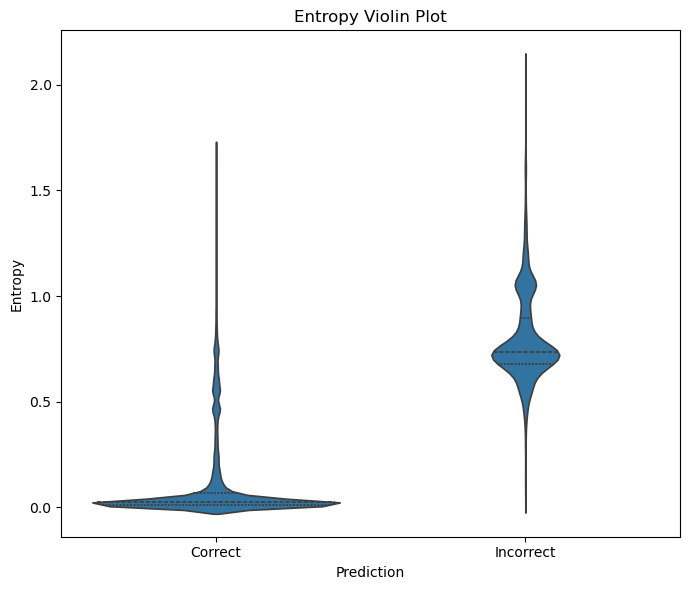

In [29]:
plt.figure(figsize=(7,6))

sns.violinplot(
    x="Prediction",
    y="Entropy",
    data=entropy_data,
    inner="quartile"
)

plt.title("Entropy Violin Plot")

plt.tight_layout()

plt.savefig(
    "Entropy_Violin.png",
    dpi=300
)

plt.show()

# Uncertainty Violin Plot

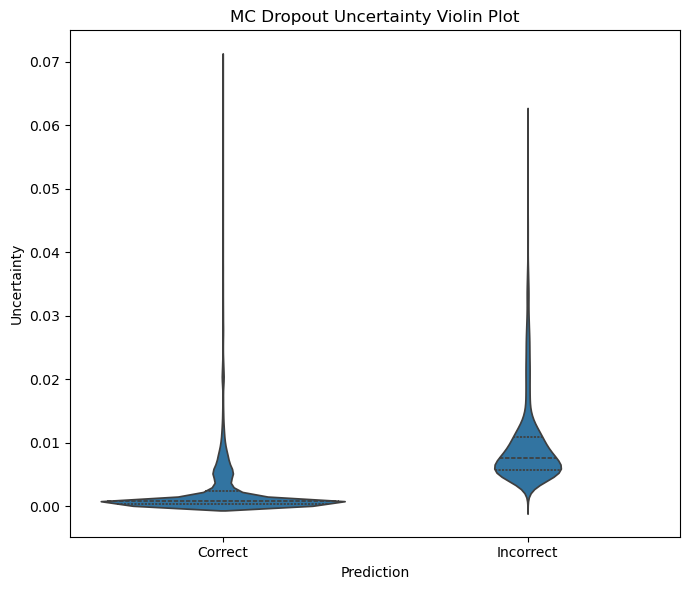

In [30]:
plt.figure(figsize=(7,6))

sns.violinplot(
    x="Prediction",
    y="Uncertainty",
    data=unc_data,
    inner="quartile"
)

plt.title("MC Dropout Uncertainty Violin Plot")

plt.tight_layout()

plt.savefig(
    "Uncertainty_Violin.png",
    dpi=300
)

plt.show()

# KDE Density Plot

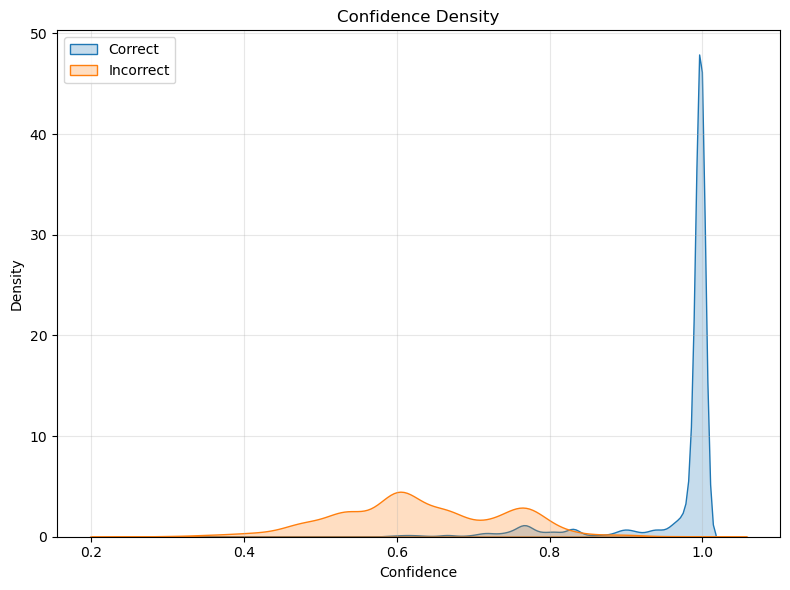

In [31]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    confidence[correct_mask],
    label="Correct",
    fill=True
)

sns.kdeplot(
    confidence[wrong_mask],
    label="Incorrect",
    fill=True
)

plt.xlabel("Confidence")

plt.ylabel("Density")

plt.title("Confidence Density")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Confidence_KDE.png",
    dpi=300
)

plt.show()

# Compute Bayesian Metrics

In [33]:
# Load MC predictions
with h5py.File("mc_predictions.h5", "r") as f:
    mc_predictions = f["predictions"][:]

print(mc_predictions.shape)

# Mean predictive probability
mean_probs = np.mean(mc_predictions, axis=0)

epsilon = 1e-10

# --------------------------
# Predictive Entropy
# --------------------------

predictive_entropy = -np.sum(
    mean_probs * np.log(mean_probs + epsilon),
    axis=1
)

# --------------------------
# Expected Entropy
# --------------------------

expected_entropy = -np.mean(

    np.sum(
        mc_predictions * np.log(mc_predictions + epsilon),
        axis=2
    ),

    axis=0
)

# --------------------------
# Mutual Information (BALD)
# --------------------------

mutual_information = (

    predictive_entropy

    -

    expected_entropy

)

# --------------------------
# Variation Ratio
# --------------------------

mc_classes = np.argmax(
    mc_predictions,
    axis=2
)

variation_ratio = []

MC_RUNS = mc_classes.shape[0]

for i in range(mc_classes.shape[1]):

    counts = np.bincount(
        mc_classes[:, i]
    )

    variation_ratio.append(

        1 - np.max(counts) / MC_RUNS

    )

variation_ratio = np.array(
    variation_ratio
)

print("Done")

(30, 487139, 14)
Done


# Print Statistics

In [34]:
print("Predictive Entropy")

print(
    predictive_entropy.mean(),
    predictive_entropy.std()
)

print()

print("Expected Entropy")

print(
    expected_entropy.mean(),
    expected_entropy.std()
)

print()

print("Mutual Information")

print(
    mutual_information.mean(),
    mutual_information.std()
)

print()

print("Variation Ratio")

print(
    variation_ratio.mean(),
    variation_ratio.std()
)

Predictive Entropy
0.11731973 0.21098919

Expected Entropy
0.107567035 0.20437665

Mutual Information
0.00975269 0.022869451

Variation Ratio
0.0024145743480471346 0.02111403031236985


# Mutual Information Histogram

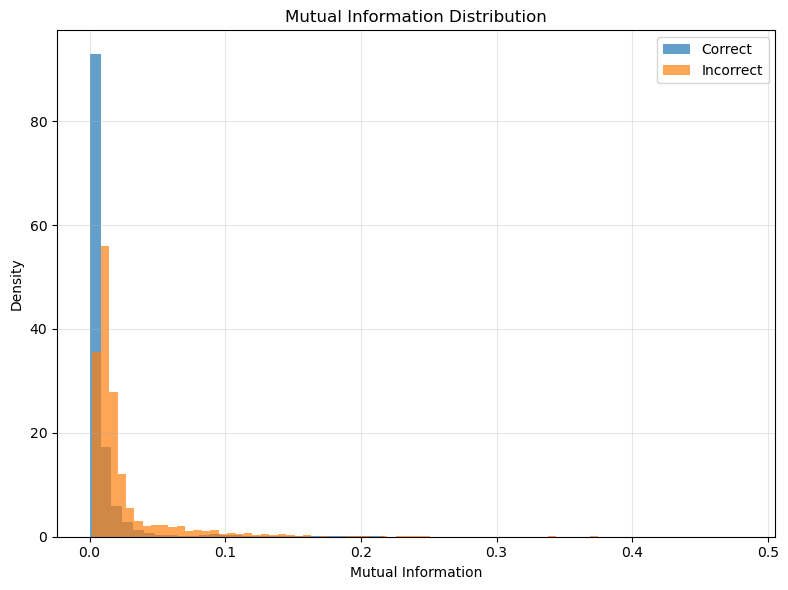

In [35]:
plt.figure(figsize=(8,6))

plt.hist(
    mutual_information[correct_mask],
    bins=60,
    alpha=0.7,
    density=True,
    label="Correct"
)

plt.hist(
    mutual_information[wrong_mask],
    bins=60,
    alpha=0.7,
    density=True,
    label="Incorrect"
)

plt.xlabel("Mutual Information")

plt.ylabel("Density")

plt.title("Mutual Information Distribution")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Mutual_Information_Histogram.png",
    dpi=300
)

plt.show()

# Variation Ratio Histogram

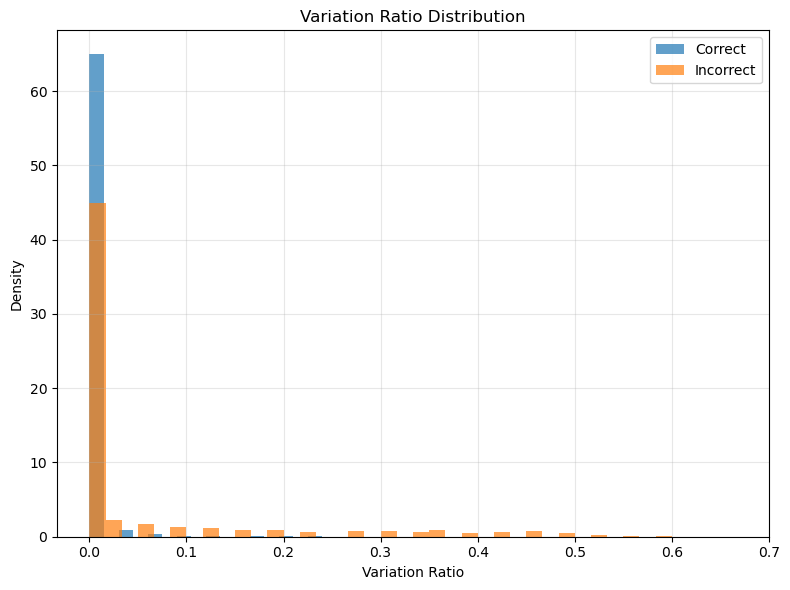

In [36]:
plt.figure(figsize=(8,6))

plt.hist(
    variation_ratio[correct_mask],
    bins=40,
    density=True,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    variation_ratio[wrong_mask],
    bins=40,
    density=True,
    alpha=0.7,
    label="Incorrect"
)

plt.xlabel("Variation Ratio")

plt.ylabel("Density")

plt.title("Variation Ratio Distribution")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Variation_Ratio_Histogram.png",
    dpi=300
)

plt.show()

# Expected Entropy Histogram

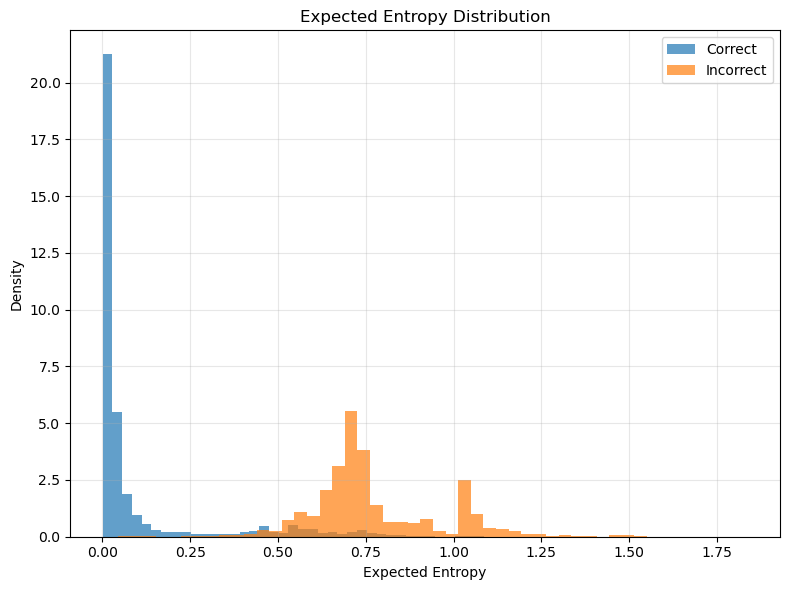

In [37]:
plt.figure(figsize=(8,6))

plt.hist(
    expected_entropy[correct_mask],
    bins=50,
    density=True,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    expected_entropy[wrong_mask],
    bins=50,
    density=True,
    alpha=0.7,
    label="Incorrect"
)

plt.xlabel("Expected Entropy")

plt.ylabel("Density")

plt.title("Expected Entropy Distribution")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Expected_Entropy_Histogram.png",
    dpi=300
)

plt.show()

# Boxplots

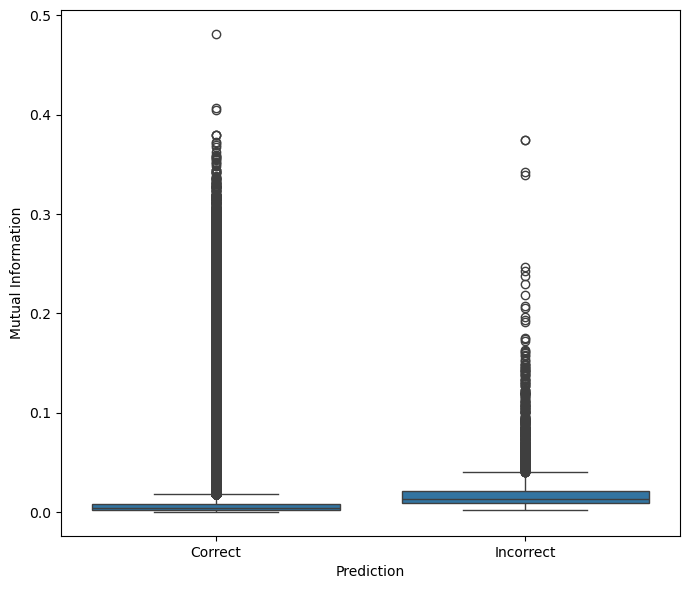

In [38]:
mi_df = pd.DataFrame({

    "Mutual Information":
        np.concatenate([
            mutual_information[correct_mask],
            mutual_information[wrong_mask]
        ]),

    "Prediction":
        ["Correct"]*np.sum(correct_mask)
        +
        ["Incorrect"]*np.sum(wrong_mask)
})

plt.figure(figsize=(7,6))

sns.boxplot(
    x="Prediction",
    y="Mutual Information",
    data=mi_df
)

plt.tight_layout()

plt.savefig(
    "Mutual_Information_Boxplot.png",
    dpi=300
)

plt.show()

# Statistical Significance

In [39]:
from scipy.stats import ttest_ind

metrics = {
    "Predictive Entropy": predictive_entropy,
    "Expected Entropy": expected_entropy,
    "Mutual Information": mutual_information,
    "Variation Ratio": variation_ratio
}

for name, values in metrics.items():

    t, p = ttest_ind(
        values[correct_mask],
        values[wrong_mask],
        equal_var=False
    )

    print(f"\n{name}")
    print(f"T-statistic : {t:.4f}")
    print(f"P-value     : {p:.4e}")


Predictive Entropy
T-statistic : -187.2609
P-value     : 0.0000e+00

Expected Entropy
T-statistic : -197.8949
P-value     : 0.0000e+00

Mutual Information
T-statistic : -24.4449
P-value     : 0.0000e+00

Variation Ratio
T-statistic : -24.3626
P-value     : 2.4200e-120


# Risk–Coverage Curve

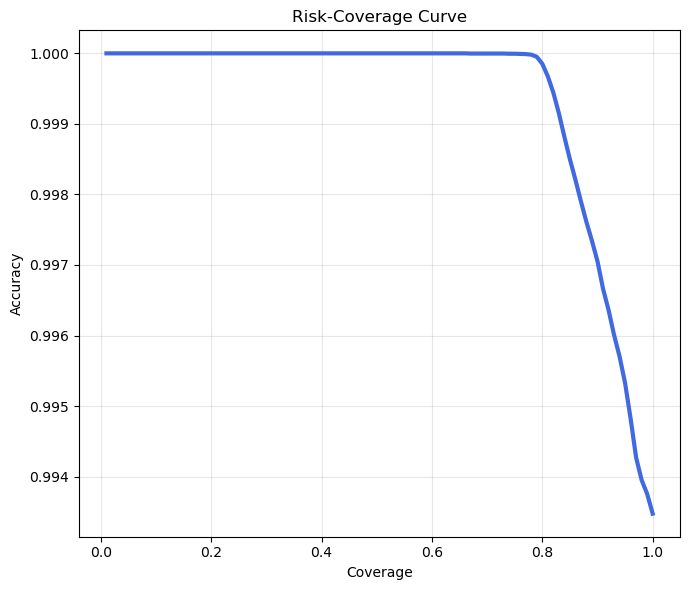

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# prediction_uncertainty
# pred_classes
# true_classes

order = np.argsort(prediction_uncertainty)

sorted_true = true_classes[order]
sorted_pred = pred_classes[order]

coverage = []
accuracy = []

N = len(sorted_true)

for i in range(100):

    keep = int(N * (i + 1) / 100)

    acc = accuracy_score(
        sorted_true[:keep],
        sorted_pred[:keep]
    )

    coverage.append(keep / N)

    accuracy.append(acc)

plt.figure(figsize=(7,6))

plt.plot(
    coverage,
    accuracy,
    linewidth=3,
    color="royalblue"
)

plt.xlabel("Coverage")

plt.ylabel("Accuracy")

plt.title("Risk-Coverage Curve")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Risk_Coverage_Curve.png",
    dpi=300
)

plt.show()

# Accuracy–Rejection Curve

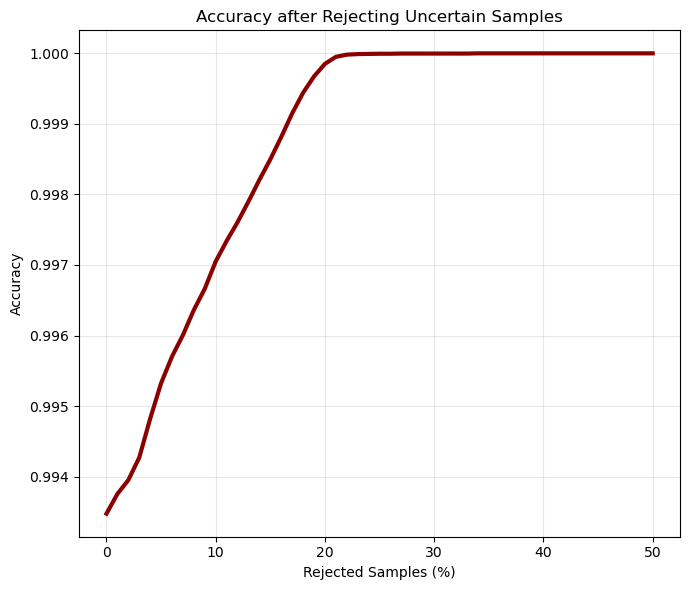

In [41]:

fractions = np.linspace(0,0.5,51)

accs=[]

for frac in fractions:

    threshold = np.quantile(
        prediction_uncertainty,
        1-frac
    )

    keep = prediction_uncertainty <= threshold

    acc = accuracy_score(

        true_classes[keep],

        pred_classes[keep]

    )

    accs.append(acc)

plt.figure(figsize=(7,6))

plt.plot(

    fractions*100,

    accs,

    linewidth=3,

    color="darkred"

)

plt.xlabel("Rejected Samples (%)")

plt.ylabel("Accuracy")

plt.title("Accuracy after Rejecting Uncertain Samples")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    "Accuracy_Rejection_Curve.png",

    dpi=300

)

plt.show()

In [42]:
results = pd.DataFrame({

    "Rejected (%)":fractions*100,

    "Accuracy":accs

})

results.to_csv(

    "Accuracy_Rejection_Table.csv",

    index=False

)

print(results.head())

   Rejected (%)  Accuracy
0           0.0  0.993474
1           1.0  0.993754
2           2.0  0.993951
3           3.0  0.994269
4           4.0  0.994821
